# QF 627 Programming and Computational Finance
## Problem Set `5` | `Questions`

> Hi Team! 👋

> The current problem set has two main parts. Questions 1 through 7 are scenario-based, giving you a taste of day-to-day operations as a buy-side Quant in the field. Questions 8 through 12 will help you explore a technical indicator for detecting momentum signals—namely, the Moving Average Convergence Divergence (MACD).

> As always, these questions have been carefully designed to guide your optimal learning. While you read and answer the questions, you’ll be able to feel my affection for you all 🙌

> Enjoy 🤗

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 through 7 are based on the following scenario. After reading it, please respond to the associated sub-questions.

> Suppose that you've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

In [11]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe_ratio() | Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std()

# compute_sharpe_ratio(ibm['strategy_returns'])

In [ ]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr() | Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    Usage:
        compute_CAGR(df['cum_strategy_returns'])
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.0 / n_of_days)
        - 1
    )
    return cagr

### <font color = blue> 👉 Question 1</font>. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

1. download data
2. calculate return and cum return
3. calculate sharpe
4. calculate mdd and ldd

### <font color = red> Answer 1 is presented in the cell below: </font>

In [13]:
df = \
pd.read_csv('alphas.csv', 
            index_col = 0, 
            parse_dates=True)

In [7]:
df

,Alphas A,Alphas B,Alphas C
2019-05-28,100.000000,100.000000,100.000000
2019-05-29,100.562415,101.991696,100.733993
2019-05-30,98.903615,104.527038,100.568916
2019-05-31,101.046406,107.799053,99.186270
2019-06-03,101.649234,107.750748,101.323467
...,...,...,...
2023-09-06,87.171517,85.212876,88.864669
2023-09-07,87.770479,85.143390,87.782382
2023-09-08,88.204118,84.376805,87.391530
2023-09-11,88.475733,85.531184,86.241478


In [14]:
compute_sharpe_ratio(df.pct_change())

Alphas A   -0.057912
Alphas B   -0.067833
Alphas C   -0.062779
dtype: float64

should consider MDD and LDD too

### <font color = blue> 👉 Question 2</font>. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha, using both lets-plot and matplotlib libraries.

### <font color = red> Answer 2 is presented in the cell below: </font>

In [19]:
alpha_returns =\
(
    np.log(
        df
        /
        df.shift(1)
    )
)
alphas_cumulative_returns = alpha_returns.cumsum().apply(np.exp)

<Axes: >

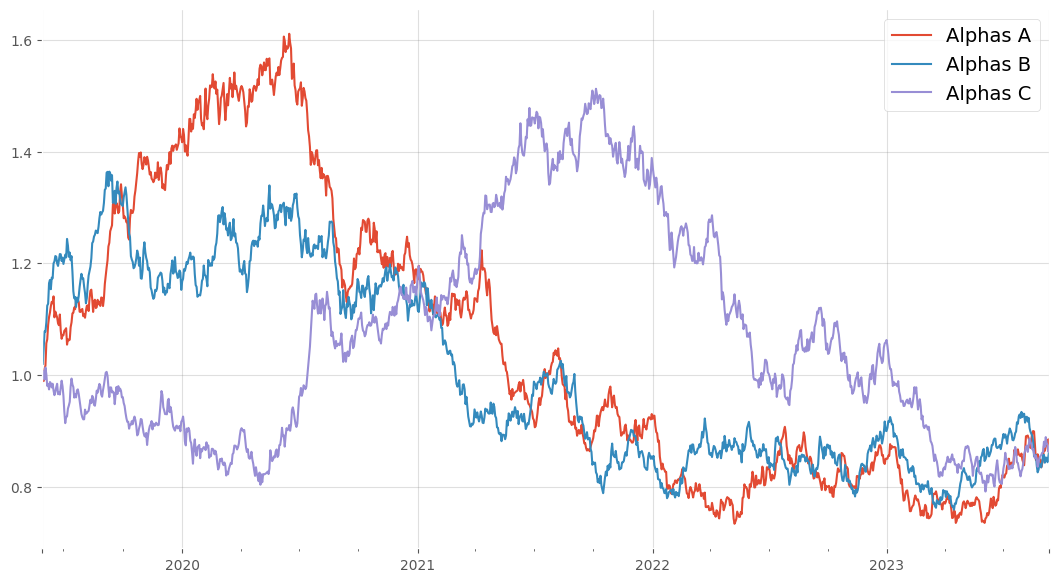

In [22]:
alphas_cumulative_returns.plot(
    figsize = [13,7]
)

In [10]:
from lets_plot import *
LetsPlot.setup_html()

In [26]:
# p =\
# (
#     ggplot(cum_rets.reset_index().rename(columns ={'index': 'Date'}), aes(x='Date')) +
#     geom_line(aes(y='Alphas A'), size=0.8, color='orange') + 
#     geom_line(aes(y='Alphas B'), size=0.8, color='blue') + 
#     geom_line(aes(y='Alphas C'), size=0.8, color='purple') + 
#     ggtitle("Cum rets of alphas") +
#     ggsize(1200, 600)
    
# )
# p

### <font color = blue> 👉 Question 3</font>. Cumulative Returns Over a 1120-Day Horizon:

- Extrapolate the cumulative returns for each Alpha over this period.
  
- When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

### <font color = red> Answer 3 is presented in the cell below: </font>

In [27]:
alphas_cumulative_returns

,Alphas A,Alphas B,Alphas C
2019-05-28,NaN,NaN,NaN
2019-05-29,1.005624,1.019917,1.007340
2019-05-30,0.989036,1.045270,1.005689
2019-05-31,1.010464,1.077991,0.991863
2019-06-03,1.016492,1.077507,1.013235
...,...,...,...
2023-09-06,0.871715,0.852129,0.888647
2023-09-07,0.877705,0.851434,0.877824
2023-09-08,0.882041,0.843768,0.873915
2023-09-11,0.884757,0.855312,0.862415


In [28]:
compute_CAGR(alphas_cumulative_returns)

Alphas A   -0.032403
Alphas B   -0.037295
Alphas C   -0.033521
dtype: float64

### <font color = blue> 👉 Question 4</font>. Maximum Draw-down (MDD):

- Assess the Maximum Drawdown (MDD) for each model within this time frame.

- Based on this assessment, which Alpha appears best equipped to withstand market downturns?

### <font color = red> Answer 4 is presented in the cell below: </font>

In [36]:
def get_drawdowns(cum_returns):
    """
    Calculate the Maximum Drawdown (MDD) and the Longest Drawdown Duration (LDD)
    from a cumulative returns SERIES.

    Parameters:
      cum_returns : pd.SERIES of cumulative returns
    Returns:
      tuple (mdd, ldd)
    Usage: 
      get_drawdowns(df['cum_strategy_returns'])
    """
    def compute_longest_drawdown_period(dd, cum_returns):
      periods =\
      (
          np
          .diff(np.append(dd[dd == 0].index,
                          dd.index[-1: ]
                        )
              )
      )
      return periods.max() / np.timedelta64(1, "D")
    
    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    mdd = daily_drawdown.min()
    ldd = compute_longest_drawdown_period(daily_drawdown, cum_returns) # days
    return mdd, ldd


# get_drawdowns(cum_rets['Alphas A'])

In [37]:
mdd_dict = {}
ldd_dict = {}

for alpha in alphas_cumulative_returns.columns:
    mdd_dict[alpha], ldd_dict[alpha] = get_drawdowns(alphas_cumulative_returns[alpha])

In [38]:
mdd_dict

{'Alphas A': np.float64(-0.544601997329252),
 'Alphas B': np.float64(-0.4437168929094025),
 'Alphas C': np.float64(-0.47675847269710636)}

In [39]:
mdd = pd.Series(mdd_dict)
mdd

Alphas A   -0.544602
Alphas B   -0.443717
Alphas C   -0.476758
dtype: float64

### <font color = blue> 👉 Question 5</font>. Examining Drawdown Duration:

- Analyze the longest drawdown durations for each strategy.

- Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

### <font color = red> Answer 5 is presented in the cell below: </font>

In [40]:
ldd = pd.Series(ldd_dict)
ldd

Alphas A    1183.0
Alphas B    1463.0
Alphas C     706.0
dtype: float64

### <font color = blue> 👉 Question 6</font>. Comprehensive Assessment of Strategy Performance:

- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. 

- Rank and justify your recommendations based on your quantitative insights.

### <font color = red> Answer 6 is presented in the cell below: </font>

In [19]:
metrics =\
(
    pd.DataFrame({
        "sharpe": sharpe, 
        "cagr": cagr, 
        "mdd": mdd, 
        "ldd": ldd})
)

In [20]:
metrics

,sharpe,cagr,mdd,ldd
Alphas A,-0.155761,-0.030094,-0.544602,846
Alphas B,-0.165297,-0.031762,-0.443717,1046
Alphas C,-0.160180,-0.030805,-0.476758,505


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

metrics_subset_normalized =\
(
    scaler
    .fit_transform(metrics)
)
metrics_subset_normalized = pd.DataFrame(metrics_subset_normalized,
                                            columns=metrics.columns,
                                            index=metrics.index)


In [22]:
metrics_subset_normalized

,sharpe,cagr,mdd,ldd
Alphas A,1.193867,1.160170,-1.339272,0.210433
Alphas B,-1.253448,-1.280445,1.063034,1.105894
Alphas C,0.059581,0.120275,0.276238,-1.316327


Metric will be `sharpe / (mdd+ldd)`

In [23]:
new_metric =\
metrics_subset_normalized['sharpe'] / \
(metrics_subset_normalized['mdd'] + metrics_subset_normalized['ldd'])

new_metric

Alphas A   -1.057606
Alphas B   -0.577911
Alphas C   -0.057284
dtype: float64

### <font color = blue> 👉 Question 7</font>. Reflecting on the Sharpe Ratio:

- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio.

- Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

### <font color = red> Answer 7 is presented in the cell below: </font>

use a metric to find the area of drawdown and average it. Use that to discount sharpe

In [24]:
sharpe / ((cum_rets / cum_rets.cummax() -1).sum() / cum_rets.shape[0]) 

Alphas A    0.497287
Alphas B    0.643443
Alphas C    0.930743
dtype: float64

## 👇 Questions 8 to 12 ask you to build, execute, and backtest a strategy based on one kind of momentum strategy called the `Moving Average Convergence Divergence` (MACD) crossover.

### <font color = blue> 👉 Question 8</font>. Let’s take a look at Apple (AAPL) as our security of interest, over the three-year period of 2015 through 2017.

#### Moving Average Convergence Divergence (`MACD`) is a lagging, trend-following momentum indicator reflecting the relationship between two moving averages of stock prices.

#### The strategy utilizes two indicators, the MACD and the MACD signal line:

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD `signal line` is then defined as the `9`-day ***exponential*** moving average of the MACD.

### <font color = green> NOTE: The MACD crossover strategy is defined as:

- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.

### Visualize your buy and sell positions.

1. download aapl from 2015 to 2017
2. calculate momentum strat
3. calculate macd and macd signal line
4. get position and trade columns
5. plot buy and sell

### Below are the lines of code that lead to an answer:

In [86]:
# TODO yf download
df=\
yf.download(
    ['AAPL'],
    start = '2014-11-01',
    end = '2018-01-01'
)['Close']



/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_47830/2968046306.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  1 of 1 completed


### <font color = red> Answer 8 is presented in the cell below: </font>

In [87]:
# st, lg = 12,26
# df['macd'] =\
# (
#     df['AAPL'].ewm(span=st, min_periods=st).mean() - \
#         df['AAPL'].ewm(span=lg, min_periods=lg).mean() 
# )
# df

In [88]:
def compute_MACD(
    df: pd.DataFrame,
    span: list[int, int, int]
    ) -> pd.DataFrame:
    """
    Compute MACD and signal-line for AAPL prices and attach intermediate EWMAs.
    Assumes first col is ticker data

    Parameters
        df : pandas.DataFrame Time-indexed DataFrame containing a column named "AAPL" with price data.
        span : list[int, int, int] Three integers specifying spans for exponential moving averages:
    Returns:
        pandas.DataFrame
    Usage:
        compute_MACD(aapl, [12, 26, 9])
    """
    df[f"_{span[0]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[0]
            )
        .mean()
    )

    df[f"_{span[1]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[1]
            )
        .mean()
    )

    df["macd"] =\
    (
        df
        .eval(
            f"`_{span[0]}_ewma` - `_{span[1]}_ewma`"
        )
    )

    df["signal"] =\
    (
        df
        ["macd"]
        .ewm(span = span[2]
            )
        .mean()
    )
    return df

In [89]:
compute_MACD(df, [12, 26, 9]
            )

Ticker,AAPL,_12_ewma,_26_ewma,macd,signal
Date,,,,,
2014-11-03,24.171764,24.171764,24.171764,0.000000,0.000000
2014-11-04,23.995008,24.076022,24.079987,-0.003966,-0.002203
2014-11-05,24.052454,24.066823,24.070095,-0.003272,-0.002641
2014-11-06,24.121246,24.084002,24.084395,-0.000392,-0.001879
2014-11-07,24.190039,24.112812,24.108894,0.003918,-0.000155
...,...,...,...,...,...
2017-12-22,41.025650,40.689051,40.313682,0.375369,0.345253
2017-12-26,39.984829,40.580709,40.289322,0.291387,0.334480
2017-12-27,39.991859,40.490117,40.267288,0.222829,0.312150


In [90]:
# df['positions'] =\
# (
#     np.where(df['macd'] > df['signal'], 1, -1)
# )
# df['trade'] =\
# (
#     df['positions'].diff()
# )
# df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions'] *2

In [ ]:
def get_signal_macd(
    df: pd.DataFrame
    ) -> pd.DataFrame:
    """
    Detect MACD/Signal-line crossovers and produce trade signals and next-bar positions.
        - The .shift(1) on 'positions' is intentional to prevent look-ahead bias: a signal at time t
        is executed at t+1.
    Parameters
        df : pandas.DataFrame Time-indexed DataFrame that must contain the columns:
        - 'macd' : the MACD line values
        - 'signal' : the MACD signal line values
        The function mutates df in-place and also returns it.
    Returns:
        pandas.DataFrame
    Usage:
        get_signal_macd(df)
    """

    df["trade"] =\
    (
        np
        .select(
            [
                (df["macd"] > df["signal"]) & (df["macd"].shift(1) < df["signal"]), # 1
                (df["macd"] < df["signal"]) & (df["macd"].shift(1) > df["signal"]), # -1
            ],
            [1, -1],
            default = np.nan
        )
    )

    df["positions"] =\
    (
        df
        ["trade"]
        .ffill()
        .shift(1)       # shift 1 to prevent lookback bias
        .fillna(0)
    )

#### optinal choice of yours
    # threshold = 0.0
    # (df["MACD"] > df["signal_line"] + threshold) 
    # team, this will prevent flip-flopping around minor crossings (NOISE) !!!
    # it's all about the signal detection from noise!!!
    return df

get_signal_macd(df)

Ticker,AAPL,_12_ewma,_26_ewma,macd,signal,trade,positions
Date,,,,,,,
2014-11-03,24.171764,24.171764,24.171764,0.000000,0.000000,NaN,0.0
2014-11-04,23.995008,24.076022,24.079987,-0.003966,-0.002203,-1.0,0.0
2014-11-05,24.052454,24.066823,24.070095,-0.003272,-0.002641,NaN,-1.0
2014-11-06,24.121246,24.084002,24.084395,-0.000392,-0.001879,1.0,-1.0
2014-11-07,24.190039,24.112812,24.108894,0.003918,-0.000155,1.0,1.0
...,...,...,...,...,...,...,...
2017-12-22,41.025650,40.689051,40.313682,0.375369,0.345253,NaN,1.0
2017-12-26,39.984829,40.580709,40.289322,0.291387,0.334480,-1.0,1.0
2017-12-27,39.991859,40.490117,40.267288,0.222829,0.312150,NaN,-1.0


In [92]:
df.trade.value_counts()

trade
 1.0    38
-1.0    33
Name: count, dtype: int64

In [93]:
df = df.reset_index()
p =\
(
    ggplot(df.reset_index(), aes(x='Date')) + 
    geom_line(aes(y='AAPL'), color='grey', size=0.7) +
    geom_point(aes(y='AAPL'), data=df[df['trade']==2.0], color='green', size=3) +
    geom_point(aes(y='AAPL'), data=df[df['trade']==-2.0], color='red', size=3) +
    ggsize(1200, 500)
)


p
# p = (
#     ggplot(wmt, aes(x='Date')) +
#     geom_line(aes(y='WMT'), color='grey', size=0.7) +
#     geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +
#     geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
#     geom_point(aes(y='sma_50'), data=wmt[wmt['trade']==1.0], color='red', size=3) +
#     geom_point(aes(y='sma_50'), data=wmt[wmt['trade']==-1.0], color='blue', size=3) +
#     ggtitle("Price Action with Signals") +
#     ylab("Stock Price") +
#     xlab("Date") +
#     ggsize(1200, 500) 
# )


NameError: name 'ggplot' is not defined

In [ ]:
df

Ticker,Date,AAPL,macd,signal,positions,trade
0,2015-01-02,24.261045,-0.118899,-0.104430,-1,-2.0
1,2015-01-05,23.577581,-0.203586,-0.124625,-1,0.0
2,2015-01-06,23.579794,-0.267391,-0.153596,-1,0.0
3,2015-01-07,23.910440,-0.288680,-0.180928,-1,0.0
4,2015-01-08,24.829126,-0.230729,-0.190981,-1,0.0
...,...,...,...,...,...,...
750,2017-12-22,41.025642,0.375368,0.345253,1,0.0
751,2017-12-26,39.984829,0.291386,0.334480,-1,-2.0
752,2017-12-27,39.991871,0.222829,0.312149,-1,0.0
753,2017-12-28,40.104385,0.175552,0.284830,-1,0.0


In [ ]:
p =\
(
    ggplot(df.reset_index(), aes(x='Date')) + 
    geom_line(aes(y='macd'), color='grey', size=0.7) +
    geom_line(aes(y='signal'), color='grey', size=0.7) +
    geom_point(aes(y='macd'), data=df[df['trade']==2.0], color='green', size=3) +
    geom_point(aes(y='macd'), data=df[df['trade']==-2.0], color='red', size=3) +
    ggsize(1200, 500)
)


p

### <font color = blue> 👉 Question 9</font>. Let’s suppose that you started from a $100,000 capital base for the given security.

### Given a $5 fixed commission fee per trade, how much in cumulative returns could you have had as a result of the MACD crossover strategy?

### Below are the lines of code that lead to an answer:

1. compute the passive and strat returns
<!-- 2. calculate cum returns -->
3. run strat
    - initial cap = 100_000
    - for idx, row in df.iterrows():
        - calculate new cap
            - capital = capital * strat_return.apply(np.exp)
        - if trade != 0:
            capital -= 5



In [ ]:
df = df.set_index('Date')

In [ ]:
df

Ticker,AAPL,macd,signal,positions,trade
Date,,,,,
2015-01-02,24.261045,-0.118899,-0.104430,-1,-2.0
2015-01-05,23.577581,-0.203586,-0.124625,-1,0.0
2015-01-06,23.579794,-0.267391,-0.153596,-1,0.0
2015-01-07,23.910440,-0.288680,-0.180928,-1,0.0
2015-01-08,24.829126,-0.230729,-0.190981,-1,0.0
...,...,...,...,...,...
2017-12-22,41.025642,0.375368,0.345253,1,0.0
2017-12-26,39.984829,0.291386,0.334480,-1,-2.0
2017-12-27,39.991871,0.222829,0.312149,-1,0.0


In [ ]:
df['passive_return'] =\
(
    np.log(df['AAPL'] / df['AAPL'].shift(1))
)
df['strategy_return'] =\
(
    df['passive_return'] * df['positions'].shift(1)
)
df = df.fillna(0)

In [ ]:
df

Ticker,AAPL,macd,signal,positions,trade,passive_return,strategy_return
Date,,,,,,,
2015-01-02,24.261045,-0.118899,-0.104430,-1,-2.0,0.000000,0.000000
2015-01-05,23.577581,-0.203586,-0.124625,-1,0.0,-0.028576,0.028576
2015-01-06,23.579794,-0.267391,-0.153596,-1,0.0,0.000094,-0.000094
2015-01-07,23.910440,-0.288680,-0.180928,-1,0.0,0.013925,-0.013925
2015-01-08,24.829126,-0.230729,-0.190981,-1,0.0,0.037702,-0.037702
...,...,...,...,...,...,...,...
2017-12-22,41.025642,0.375368,0.345253,1,0.0,0.000000,0.000000
2017-12-26,39.984829,0.291386,0.334480,-1,-2.0,-0.025697,-0.025697
2017-12-27,39.991871,0.222829,0.312149,-1,0.0,0.000176,-0.000176


In [ ]:
initial_cap = 100_000

In [ ]:
cap = initial_cap

for idx, row in df.iterrows():
    cap = cap * np.exp(row['strategy_return'])
    if row['trade'] == 2 or row['trade'] == -2.0:
        cap -= 5

In [ ]:
df['passive_return'].sum()

np.float64(0.491741270027385)

In [ ]:
cap

np.float64(188597.20014782174)

### <font color = red> Answer 9 </font>

    The answer is ____________ % .

In [ ]:
cagr =\
    (cap / initial_cap) ** (252 / (df.shape[0]-1)) - 1

In [ ]:
print(f'The answer is {cagr:.3%}')

The answer is 23.620%


### <font color = blue> 👉 Question 10</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [ ]:
df['strategy_cum_returns'] =\
(
    df['strategy_return'].cumsum().apply(np.exp)
)
df['daily_drawdown'] =\
(
    df['strategy_cum_returns'] / df['strategy_cum_returns'].cummax() - 1 
)

In [ ]:
"""
 TODO max drawdown and duration table
"""
# take date column out and cumsum for periods
dd_reset = df.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)

<Axes: xlabel='Date'>

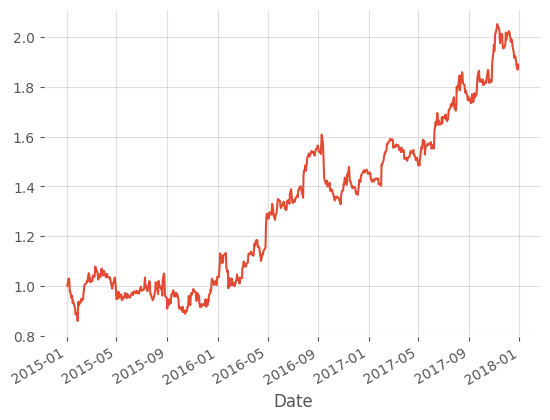

In [ ]:
df['strategy_cum_returns'].plot()

In [ ]:
period_stats

,start_date,end_date,avg_dd,max_dd,duration
period,,,,,
5,2015-03-12,2016-01-05,-0.094411,-0.176032,207
40,2016-09-12,2017-06-08,-0.082749,-0.174034,187
2,2015-01-06,2015-02-20,-0.073511,-0.165220,32
8,2016-01-22,2016-03-21,-0.072505,-0.125381,41
57,2017-08-16,2017-09-22,-0.044608,-0.066968,27
66,2017-11-09,2017-12-29,-0.037956,-0.089113,35
13,2016-04-05,2016-04-26,-0.035226,-0.071170,16
20,2016-05-13,2016-05-24,-0.030108,-0.048266,8
52,2017-07-27,2017-08-01,-0.024436,-0.030823,4


### <font color = red> Answer 10 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

In [ ]:
for _, row in period_stats.iloc[:5].iterrows():
    print(f'Net drawdown {row['avg_dd'] * row['duration']:.2%} | Duration {row['duration']} Days')

Net drawdown -1954.31% | Duration 207 Days
Net drawdown -1547.40% | Duration 187 Days
Net drawdown -235.23% | Duration 32 Days
Net drawdown -297.27% | Duration 41 Days
Net drawdown -120.44% | Duration 27 Days


### <font color = blue> 👉 Question 11</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

In [ ]:
df

Ticker,AAPL,macd,signal,positions,trade,passive_return,strategy_return,strategy_cum_returns,daily_drawdown
Date,,,,,,,,,
2015-01-02,24.261045,-0.118899,-0.104430,-1,-2.0,0.000000,0.000000,1.000000,0.000000
2015-01-05,23.577581,-0.203586,-0.124625,-1,0.0,-0.028576,0.028576,1.028988,0.000000
2015-01-06,23.579794,-0.267391,-0.153596,-1,0.0,0.000094,-0.000094,1.028891,-0.000094
2015-01-07,23.910440,-0.288680,-0.180928,-1,0.0,0.013925,-0.013925,1.014663,-0.013921
2015-01-08,24.829126,-0.230729,-0.190981,-1,0.0,0.037702,-0.037702,0.977120,-0.050406
...,...,...,...,...,...,...,...,...,...
2017-12-22,41.025642,0.375368,0.345253,1,0.0,0.000000,0.000000,1.923618,-0.062608
2017-12-26,39.984829,0.291386,0.334480,-1,-2.0,-0.025697,-0.025697,1.874817,-0.086389
2017-12-27,39.991871,0.222829,0.312149,-1,0.0,0.000176,-0.000176,1.874486,-0.086550


In [ ]:
periods = ['2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01']
cagr = []

for i, period in enumerate(periods[:-1]):
    final = np.exp(df.loc[period: periods[i+1]]['strategy_return'].sum())
    cagr.append(final ** (252 / (df.loc[period: periods[i+1]].shape[0]-1)) - 1)
    print(period, cagr[-1])

print(f"average cagr {np.array(cagr).mean()}")

2015-01-01 0.03600432029195044
2016-01-01 0.4011458498638525
2017-01-01 0.306480026879278
average cagr 0.24787673234502697


### <font color = red> Answer 11 </font>

    Below average year(s) : ______2015______ 
    
    Above average year(s) : _____2016, 2017_______ 
     

###  <font color = blue> 👉 Question 12. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [ ]:
df['strategy_return'].mean() / df['strategy_return'].std() * np.sqrt(252) 

np.float64(0.9296323744509045)

### <font color = red> Answer 12 </font>
    
    Sharpe ratio: __________
    

### <font color="green">"💯 Thank you for putting your efforts into the exercise problem sets 😊"</font>